In [138]:
#from pathlib import Path

from amoc_analysis import data, plotting
import amocatlas
from spectra_filtering import analysis

### Load data

In [139]:
from amocatlas import read 
import numpy as np 

In [140]:
ds = read.osnap()
ds_r = read.rapid()

Loading 1 OSNAP dataset(s):
  0. OSNAP_MOC_MHT_MFT_TimeSeries_201408_202207_2025.nc: Time series of MOC, MHT, and MFT (2014-2022)

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series



In [141]:
ds

<xarray.Dataset> Size: 15kB
Dimensions:              (TIME: 96)
Coordinates:
  * TIME                 (TIME) datetime64[ns] 768B 2014-08-01T12:00:00 ... 2...
Data variables: (12/18)
    MOC_SIGMA0           (TIME) float64 768B ...
    MOC_SIGMA0_ERR       (TIME) float64 768B ...
    MOC_EAST_SIGMA0      (TIME) float64 768B ...
    MOC_EAST_SIGMA0_ERR  (TIME) float64 768B ...
    MOC_WEST_SIGMA0      (TIME) float64 768B ...
    MOC_WEST_SIGMA0_ERR  (TIME) float64 768B ...
    ...                   ...
    MFT                  (TIME) float64 768B ...
    MFT_ERR              (TIME) float64 768B ...
    MFT_EAST             (TIME) float64 768B ...
    MFT_EAST_ERR         (TIME) float64 768B ...
    MFT_WEST             (TIME) float64 768B ...
    MFT_WEST_ERR         (TIME) float64 768B ...
Attributes: (12/40)
    title:                                 OSNAP MOC MHT MFT time series (201...
    summary:                               OSNAP transport and hydrographic e...
    description:                           OSNAP transport and hydrographic e...
    program:                               OSNAP
    project:                               Overturning in the Subpolar North ...
    license:                               CC-BY-4.0
    ...                                    ...
    processing_datasource:                 osnap55n
    variable_mapping:                      {'MOC_ALL': 'MOC_SIGMA0', 'MOC_WES...
    original_variable_metadata:            {'TIME': {'long_name': 'Start date...
    applied_variable_mapping:              {'MOC_ALL': 'MOC_SIGMA0', 'MOC_WES...
    files:                                 {'OSNAP_MOC_MHT_MFT_TimeSeries_201...
    data_assembly_center:                  Georgia Institute of Technology

In [142]:
ds_r

<xarray.Dataset> Size: 1MB
Dimensions:           (TIME: 14599)
Coordinates:
  * TIME              (TIME) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Data variables:
    TRANS_0_800       (TIME) float64 117kB ...
    TRANS_800_1100    (TIME) float64 117kB ...
    TRANS_1100_3000   (TIME) float64 117kB ...
    TRANS_3000_5000   (TIME) float64 117kB ...
    TRANS_below_5000  (TIME) float64 117kB ...
    TRANS_FC          (TIME) float64 117kB ...
    TRANS_EKMAN       (TIME) float64 117kB ...
    TRANS_UMO         (TIME) float64 117kB ...
    MOC               (TIME) float64 117kB ...
Attributes: (12/39)
    title:                                 RAPID MOC timeseries
    summary:                               RAPID 26N transport estimates dataset
    description:                           RAPID 26N transport estimates dataset
    program:                               RAPID
    project:                               RAPID-AMOC 26°N array
    license:                               UK Open Government Licence v3.0 ht...
    ...                                    ...
    processing_datasource:                 rapid26n
    variable_mapping:                      {'time': 'TIME', 't_therm10': 'TRA...
    original_variable_metadata:            {'t_therm10': {'long_name': 'Trans...
    applied_variable_mapping:              {'time': 'TIME', 't_therm10': 'TRA...
    version:                               v2024.1a
    files:                                 {'moc_transports.nc': {'featureTyp...

In [143]:
moc = ds['MOC_EAST_SIGMA0']
x = moc.interpolate_na("TIME").values
# samples per day (monthly data)
fs = 1/30

In [144]:
moc_r = ds_r['MOC']
x_r = moc_r.interpolate_na("TIME").values
fs_r = 2

### periodogram

#### osnap

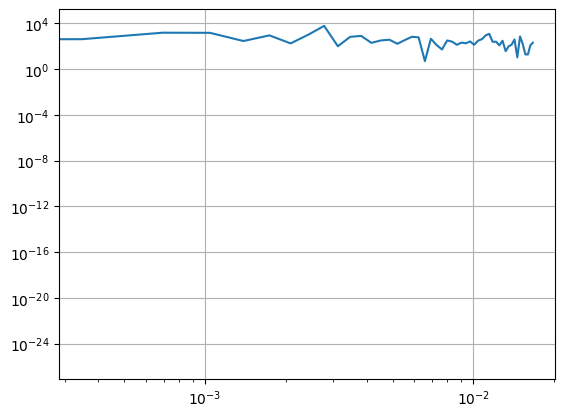

In [145]:
from scipy import signal 
import matplotlib.pyplot as plt
fs = 1/30
f, Pxx = signal.periodogram(x, fs=fs, detrend = 'linear')
plt.loglog(f, Pxx)
plt.grid()

#### rapid

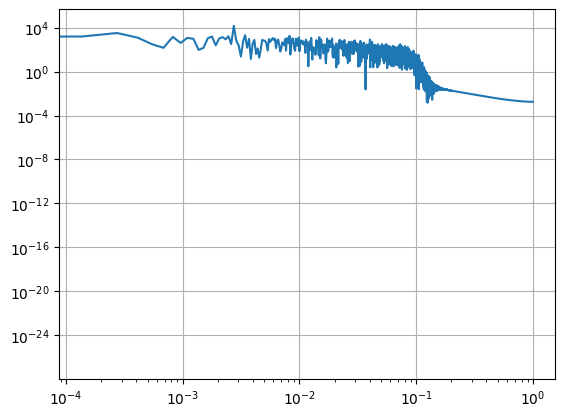

In [146]:
from scipy import signal 
import matplotlib.pyplot as plt
fs_r = 2
f_r, Pxx_r = signal.periodogram(x_r[~np.isnan(x_r)], fs=fs_r, detrend='linear')
plt.loglog(f_r, Pxx_r)
plt.grid()

### leakage and tapering

#### osnap

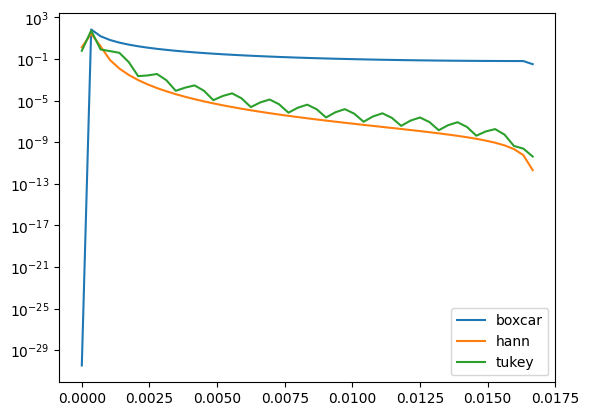

In [147]:
n, dt = 96, 1/30
t = np.arange(n) * dt
tone = np.cos(2 * np.pi * 0.06 * t)

for win in ('boxcar', 'hann', 'tukey'):
    f_r, P_r = signal.periodogram(tone, fs = fs, window=win)
    plt.semilogy(f_r, P_r, label=win)
    plt.legend()


#### rapid

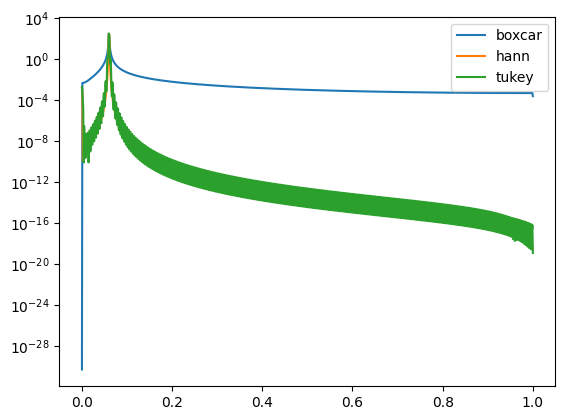

In [148]:
n_r, dt_r = 2048, 0.5
t = np.arange(n_r) * dt_r
tone = np.cos(2 * np.pi * 0.06 * t)

for win in ('boxcar', 'hann', 'tukey'):
    f_r, P_r = signal.periodogram(tone, fs = fs_r, window=win)
    plt.semilogy(f_r, P_r, label=win)
    plt.legend()

### Welch spectrum

#### osnap

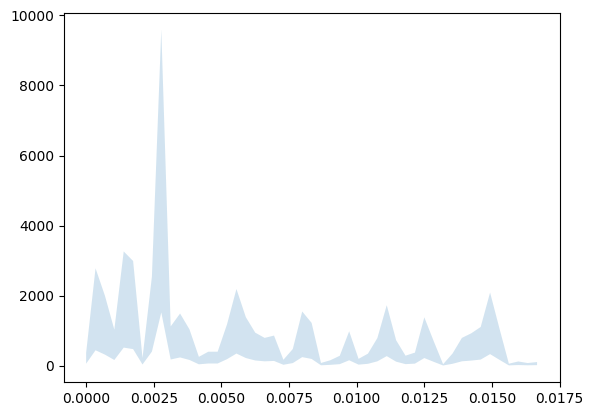

In [149]:
f, Pxx = signal.welch(x, fs=fs, window='hann', nperseg=96, noverlap=48, detrend='linear')

from scipy.stats import chi2
K = 5
dof = 2*K
lo = dof/ chi2.ppf(0.975,dof)
hi = dof/ chi2.ppf(0.025,dof)
plt.fill_between(f, Pxx*lo, Pxx*hi, alpha = 0.2)

#### rapid

(0.0, 0.2)

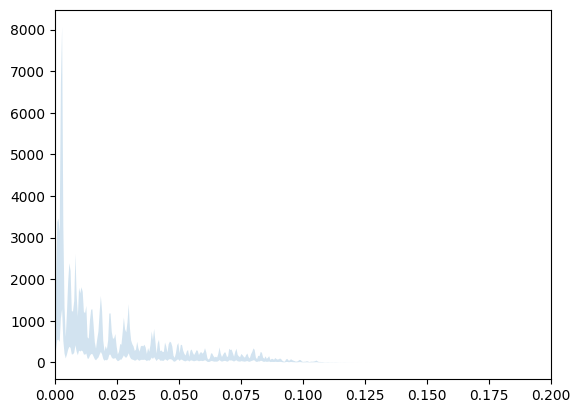

In [150]:
f_r, Pxx_r = signal.welch(x_r[~np.isnan(x_r)], fs=fs_r, window='hann', nperseg=4096, noverlap=2048, detrend='linear')

from scipy.stats import chi2
K_r = 5
dof_r = 2*K_r
lo_r = dof_r/ chi2.ppf(0.975,dof_r)
hi_r = dof_r/ chi2.ppf(0.025,dof_r)
plt.fill_between(f_r, Pxx_r*lo_r, Pxx_r*hi_r, alpha = 0.2)
plt.xlim(0, 0.2)

### Parseval check

#### osnap

In [151]:
df = f[1] - f[0]
var_psd = np.sum(Pxx) * df
print(var_psd, np.var(x))

frac = np.cumsum(Pxx) * df / var_psd
print(frac)

6.203733904921657 8.363645999887746
[0.00673231 0.05728086 0.09359404 0.11233019 0.17160464 0.22593052
 0.22995606 0.27612585 0.4505472  0.47095148 0.49803633 0.51689212
 0.52149889 0.52876087 0.53602876 0.55753791 0.59732665 0.62251167
 0.63967214 0.65410379 0.66973507 0.6728345  0.68150416 0.70963428
 0.73186144 0.73328115 0.73613232 0.74129224 0.75914066 0.76269942
 0.76896036 0.78329512 0.81469934 0.82790471 0.83311185 0.83991478
 0.86501916 0.87774874 0.87854232 0.88484495 0.8992705  0.91610098
 0.93619899 0.97416564 0.99343622 0.99448584 0.99669753 0.9980904
 1.        ]


#### rapid

In [152]:
x_r

array([nan, nan, nan, ..., nan, nan, nan], shape=(14599,))

In [153]:
df_r = f_r[1] - f_r[0]
var_psd_r = np.sum(Pxx_r) * df_r
print(var_psd_r, np.var(x_r))

frac_r = np.cumsum(Pxx_r) * df_r / var_psd
print(frac_r)

19.02288068125429 nan
[0.01014422 0.06090921 0.14712816 ... 3.06635987 3.06635987 3.06635987]


OSNAP variance: time domain = 8.3636, periodogram = 8.3387, Welch = 6.2037
OSNAP cumulative fraction at highest plotted frequency = 1.0000


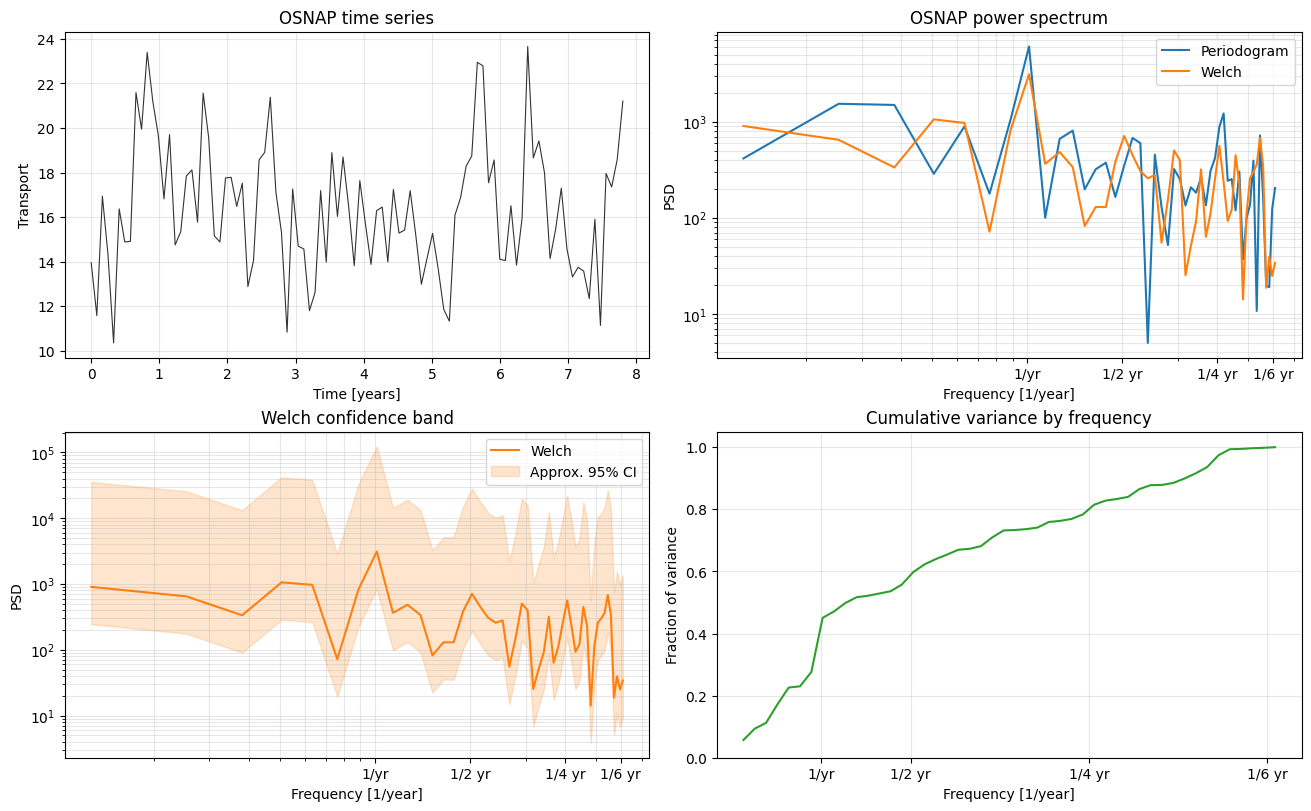

In [165]:
series_raw = np.asarray(x)
series = series_raw[np.isfinite(series_raw)]
time_years = np.arange(series_raw.size) / fs / 365.25

f_p, Pxx_p = signal.periodogram(series, fs=fs, detrend='linear')
nperseg = min(96, series.size)
overlap = max(0, nperseg // 2)
f_w, Pxx_w = signal.welch(
    series,
    fs=fs,
    window='hann',
    nperseg=nperseg,
    noverlap=overlap,
    detrend='linear',
)

df_p = f_p[1] - f_p[0]
df_w = f_w[1] - f_w[0]
var_time = np.var(series)
var_p = np.sum(Pxx_p) * df_p
var_w = np.sum(Pxx_w) * df_w
frac_w = np.cumsum(Pxx_w) * df_w / var_w

freq_p = f_p[1:] * 365.25
freq_w = f_w[1:] * 365.25
Pxx_p_plot = Pxx_p[1:]
Pxx_w_plot = Pxx_w[1:]

segments = max(1, 1 + max(0, series.size - nperseg) // max(1, nperseg - overlap))
dof = 2 * segments
lo = dof / chi2.ppf(0.975, dof)
hi = dof / chi2.ppf(0.025, dof)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

axes[0, 0].plot(time_years, series_raw, color='0.2', lw=0.8)
axes[0, 0].set_title('OSNAP time series')
axes[0, 0].set_xlabel('Time [years]')
axes[0, 0].set_ylabel('Transport')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].loglog(freq_p, Pxx_p_plot, label='Periodogram')
axes[0, 1].loglog(freq_w, Pxx_w_plot, label='Welch')
axes[0, 1].set_title('OSNAP power spectrum')
axes[0, 1].set_xlabel('Frequency [1/year]')
axes[0, 1].set_ylabel('PSD')
axes[0, 1].set_xticks([1, 2, 4, 6])
axes[0, 1].set_xticklabels(['1/yr', '1/2 yr', '1/4 yr', '1/6 yr'])
axes[0, 1].grid(True, which='both', alpha=0.3)
axes[0, 1].legend()

axes[1, 0].loglog(freq_w, Pxx_w_plot, color='C1', label='Welch')
axes[1, 0].fill_between(
    freq_w,
    Pxx_w_plot * lo,
    Pxx_w_plot * hi,
    color='C1',
    alpha=0.2,
    label='Approx. 95% CI',
)
axes[1, 0].set_title('Welch confidence band')
axes[1, 0].set_xlabel('Frequency [1/year]')
axes[1, 0].set_ylabel('PSD')
axes[1, 0].set_xticks([1, 2, 4, 6])
axes[1, 0].set_xticklabels(['1/yr', '1/2 yr', '1/4 yr', '1/6 yr'])
axes[1, 0].grid(True, which='both', alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(freq_w, frac_w[1:], color='C2')
axes[1, 1].set_title('Cumulative variance by frequency')
axes[1, 1].set_xlabel('Frequency [1/year]')
axes[1, 1].set_ylabel('Fraction of variance')
axes[1, 1].set_xticks([1, 2, 4, 6])
axes[1, 1].set_xticklabels(['1/yr', '1/2 yr', '1/4 yr', '1/6 yr'])
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].grid(True, alpha=0.3)

print(f'OSNAP variance: time domain = {var_time:.4f}, periodogram = {var_p:.4f}, Welch = {var_w:.4f}')
print(f'OSNAP cumulative fraction at highest plotted frequency = {frac_w[-1]:.4f}')

RAPID variance: time domain = 19.3754, periodogram = 19.0758, Welch = 19.0229
RAPID cumulative fraction at highest plotted frequency = 1.0000


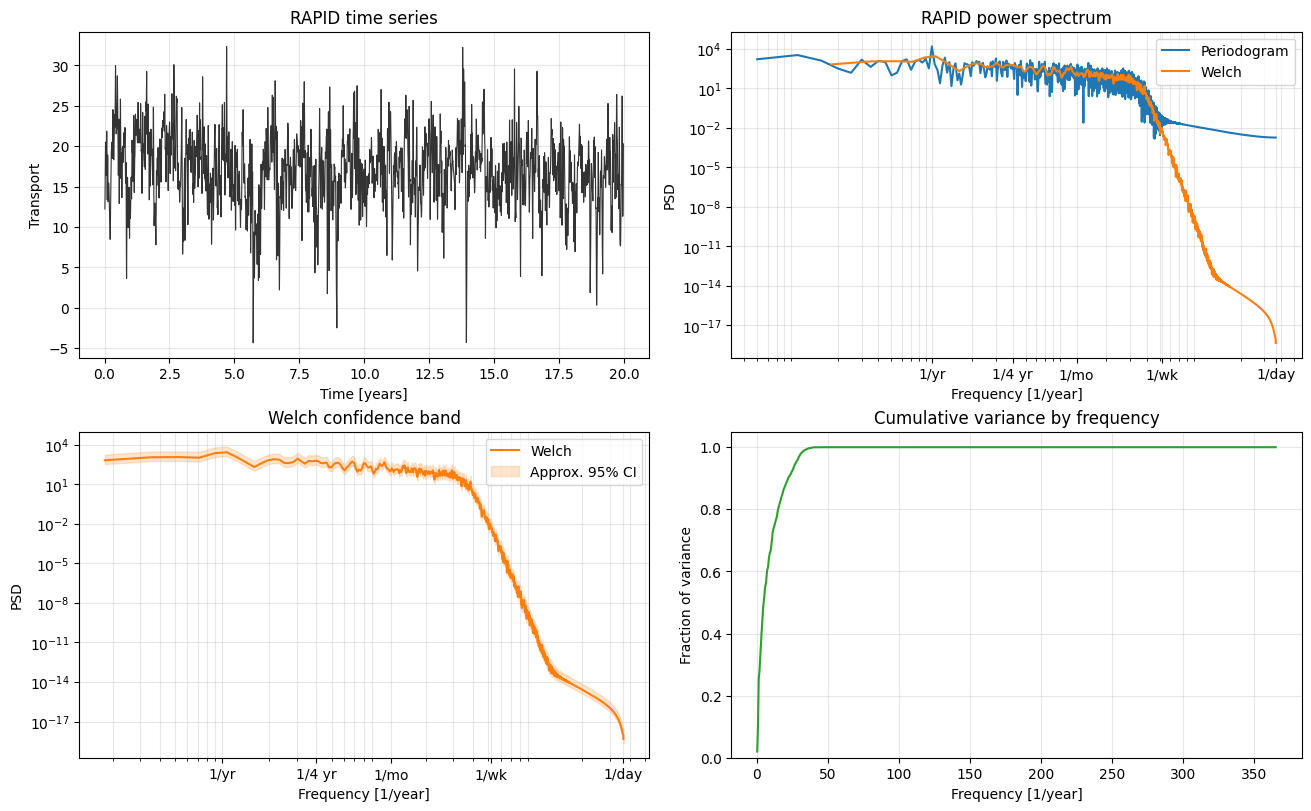

In [166]:
series_raw = np.asarray(x_r)
series = series_raw[np.isfinite(series_raw)]
time_years = np.arange(series_raw.size) / fs_r / 365.25

f_p, Pxx_p = signal.periodogram(series, fs=fs_r, detrend='linear')
nperseg = min(4096, series.size)
overlap = max(0, nperseg // 2)
f_w, Pxx_w = signal.welch(
    series,
    fs=fs_r,
    window='hann',
    nperseg=nperseg,
    noverlap=overlap,
    detrend='linear',
)

df_p = f_p[1] - f_p[0]
df_w = f_w[1] - f_w[0]
var_time = np.var(series)
var_p = np.sum(Pxx_p) * df_p
var_w = np.sum(Pxx_w) * df_w
frac_w = np.cumsum(Pxx_w) * df_w / var_w

freq_p = f_p[1:] * 365.25
freq_w = f_w[1:] * 365.25
Pxx_p_plot = Pxx_p[1:]
Pxx_w_plot = Pxx_w[1:]

segments = max(1, 1 + max(0, series.size - nperseg) // max(1, nperseg - overlap))
dof = 2 * segments
lo = dof / chi2.ppf(0.975, dof)
hi = dof / chi2.ppf(0.025, dof)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

axes[0, 0].plot(time_years, series_raw, color='0.2', lw=0.8)
axes[0, 0].set_title('RAPID time series')
axes[0, 0].set_xlabel('Time [years]')
axes[0, 0].set_ylabel('Transport')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].loglog(freq_p, Pxx_p_plot, label='Periodogram')
axes[0, 1].loglog(freq_w, Pxx_w_plot, label='Welch')
axes[0, 1].set_title('RAPID power spectrum')
axes[0, 1].set_xlabel('Frequency [1/year]')
axes[0, 1].set_ylabel('PSD')
axes[0, 1].set_xticks([1, 4, 12, 52, 365])
axes[0, 1].set_xticklabels(['1/yr', '1/4 yr', '1/mo', '1/wk', '1/day'])
axes[0, 1].grid(True, which='both', alpha=0.3)
axes[0, 1].legend()

axes[1, 0].loglog(freq_w, Pxx_w_plot, color='C1', label='Welch')
axes[1, 0].fill_between(
    freq_w,
    Pxx_w_plot * lo,
    Pxx_w_plot * hi,
    color='C1',
    alpha=0.2,
    label='Approx. 95% CI',
)
axes[1, 0].set_title('Welch confidence band')
axes[1, 0].set_xlabel('Frequency [1/year]')
axes[1, 0].set_ylabel('PSD')
axes[1, 0].set_xticks([1, 4, 12, 52, 365])
axes[1, 0].set_xticklabels(['1/yr', '1/4 yr', '1/mo', '1/wk', '1/day'])
axes[1, 0].grid(True, which='both', alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(freq_w, frac_w[1:], color='C2')
axes[1, 1].set_title('Cumulative variance by frequency')
axes[1, 1].set_xlabel('Frequency [1/year]')
axes[1, 1].set_ylabel('Fraction of variance')
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].grid(True, alpha=0.3)

print(f'RAPID variance: time domain = {var_time:.4f}, periodogram = {var_p:.4f}, Welch = {var_w:.4f}')
print(f'RAPID cumulative fraction at highest plotted frequency = {frac_w[-1]:.4f}')

OSNAP variance: time domain = 8.3636, periodogram = 8.3387, Welch = 6.2037


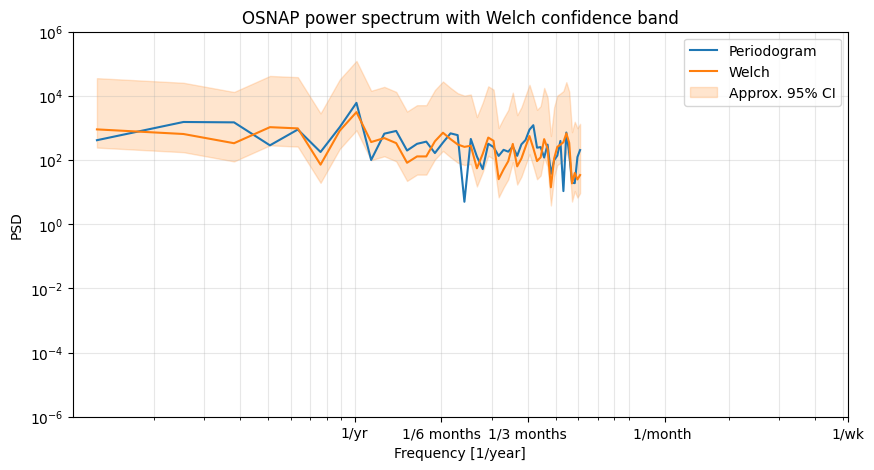

In [206]:
series_raw = np.asarray(x)
series = series_raw[np.isfinite(series_raw)]

f_p, Pxx_p = signal.periodogram(series, fs=fs, detrend='linear')
nperseg = min(96, series.size)
overlap = max(0, nperseg // 2)
f_w, Pxx_w = signal.welch(
    series,
    fs=fs,
    window='hann',
    nperseg=nperseg,
    noverlap=overlap,
    detrend='linear',
)

df_p = f_p[1] - f_p[0]
df_w = f_w[1] - f_w[0]
var_time = np.var(series)
var_p = np.sum(Pxx_p) * df_p
var_w = np.sum(Pxx_w) * df_w

segments = max(1, 1 + max(0, series.size - nperseg) // max(1, nperseg - overlap))
dof = 2 * segments
lo = dof / chi2.ppf(0.975, dof)
hi = dof / chi2.ppf(0.025, dof)

freq_p = f_p[1:] * 365.25
freq_w = f_w[1:] * 365.25
Pxx_p_plot = Pxx_p[1:]
Pxx_w_plot = Pxx_w[1:]

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(freq_p, Pxx_p_plot, label='Periodogram')
ax.loglog(freq_w, Pxx_w_plot, label='Welch')
ax.fill_between(
    freq_w,
    Pxx_w_plot * lo,
    Pxx_w_plot * hi,
    color='C1',
    alpha=0.2,
    label='Approx. 95% CI',
)
ax.set_title('OSNAP power spectrum with Welch confidence band')
ax.set_xlabel('Frequency [1/year]')
ax.set_ylabel('PSD')
axis_max = max(float(np.nanmax(freq_p)), float(np.nanmax(freq_w)))
# tick_values = [tick for tick in range(1, 11) if tick <= axis_max]
# ax.set_xticks(tick_values)
# ax.set_xticklabels(['1/yr' if tick == 1 else f'1/{tick} yr' for tick in tick_values])
ax.set_xticks([1,2, 4, 12, 52])
ax.set_xticklabels(['1/yr', '1/6 months', '1/3 months', '1/month ', '1/wk'])
ax.grid(True, which='both', alpha=0.3)
ax.legend()
ax.set_ylim(1e-6, 1e6)

print(f'OSNAP variance: time domain = {var_time:.4f}, periodogram = {var_p:.4f}, Welch = {var_w:.4f}')

RAPID variance: time domain = 19.3754, periodogram = 19.0758, Welch = 19.0229


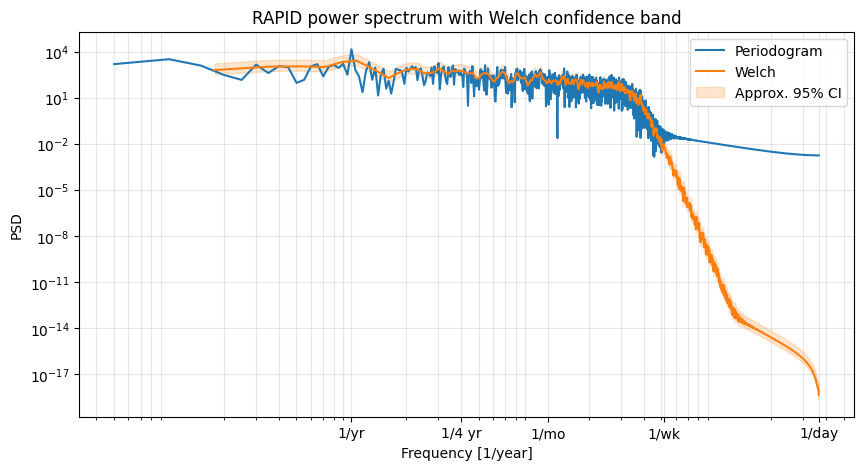

In [188]:
series_raw = np.asarray(x_r)
series = series_raw[np.isfinite(series_raw)]

f_p, Pxx_p = signal.periodogram(series, fs=fs_r, detrend='linear')
nperseg = min(4096, series.size)
overlap = max(0, nperseg // 2)
f_w, Pxx_w = signal.welch(
    series,
    fs=fs_r,
    window='hann',
    nperseg=nperseg,
    noverlap=overlap,
    detrend='linear',
)

df_p = f_p[1] - f_p[0]
df_w = f_w[1] - f_w[0]
var_time = np.var(series)
var_p = np.sum(Pxx_p) * df_p
var_w = np.sum(Pxx_w) * df_w

segments = max(1, 1 + max(0, series.size - nperseg) // max(1, nperseg - overlap))
dof = 2 * segments
lo = dof / chi2.ppf(0.975, dof)
hi = dof / chi2.ppf(0.025, dof)

freq_p = f_p[1:] * 365.25
freq_w = f_w[1:] * 365.25
Pxx_p_plot = Pxx_p[1:]
Pxx_w_plot = Pxx_w[1:]

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(freq_p, Pxx_p_plot, label='Periodogram')
ax.loglog(freq_w, Pxx_w_plot, label='Welch')
ax.fill_between(
    freq_w,
    Pxx_w_plot * lo,
    Pxx_w_plot * hi,
    color='C1',
    alpha=0.2,
    label='Approx. 95% CI',
)
ax.set_title('RAPID power spectrum with Welch confidence band')
ax.set_xlabel('Frequency [1/year]')
ax.set_ylabel('PSD')
ax.set_xticks([1, 4, 12, 52, 365])
ax.set_xticklabels(['1/yr', '1/4 yr', '1/mo', '1/wk', '1/day'])
ax.grid(True, which='both', alpha=0.3)
ax.legend()
#ax.set_ylim(1e-3, 1e3)

print(f'RAPID variance: time domain = {var_time:.4f}, periodogram = {var_p:.4f}, Welch = {var_w:.4f}')